# Практическое занятие №3

## Свёртка и корреляционный анализ сигналов

## Цели занятия
- Освоить вычисление свёртки и корреляции в Python.
- Применить свёртку для фильтрации сигналов.
- Использовать кросс-корреляцию для поиска временной задержки и обнаружения шаблона.
- Проанализировать влияние уровня шума на точность оценок.

## Подготовка окружения

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Задание 1. Свёртка гауссовых функций: сравнение численного и аналитического результатов

### Теоретическое введение
Свёртка двух гауссовых функций даёт гауссову функцию с дисперсией, равной сумме дисперсий. Если
$$
f(t) = \frac{1}{\sqrt{2\pi\sigma_1^2}} e^{-t^2/(2\sigma_1^2)}, \quad g(t) = \frac{1}{\sqrt{2\pi\sigma_2^2}} e^{-t^2/(2\sigma_2^2)},
$$
то
$$
(f * g)(t) = \frac{1}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}} e^{-t^2/(2(\sigma_1^2+\sigma_2^2))}.
$$

### Задание
1. Сгенерируйте дискретные гауссовы импульсы (например, с помощью `scipy.signal.windows.gaussian`) с заданными стандартными отклонениями `sigma1=3`, `sigma2=5`. Используйте длину окна, достаточную для захвата всей значимой части (например, 10*sigma).
2. Вычислите свёртку численно с помощью `np.convolve`.
3. Постройте графики:
   - Исходные функции.
   - Результат свёртки (численный).
   - Теоретическую гауссову функцию с дисперсией `sigma1^2 + sigma2^2`.
4. Оцените среднеквадратичную ошибку между численным и теоретическим результатами.

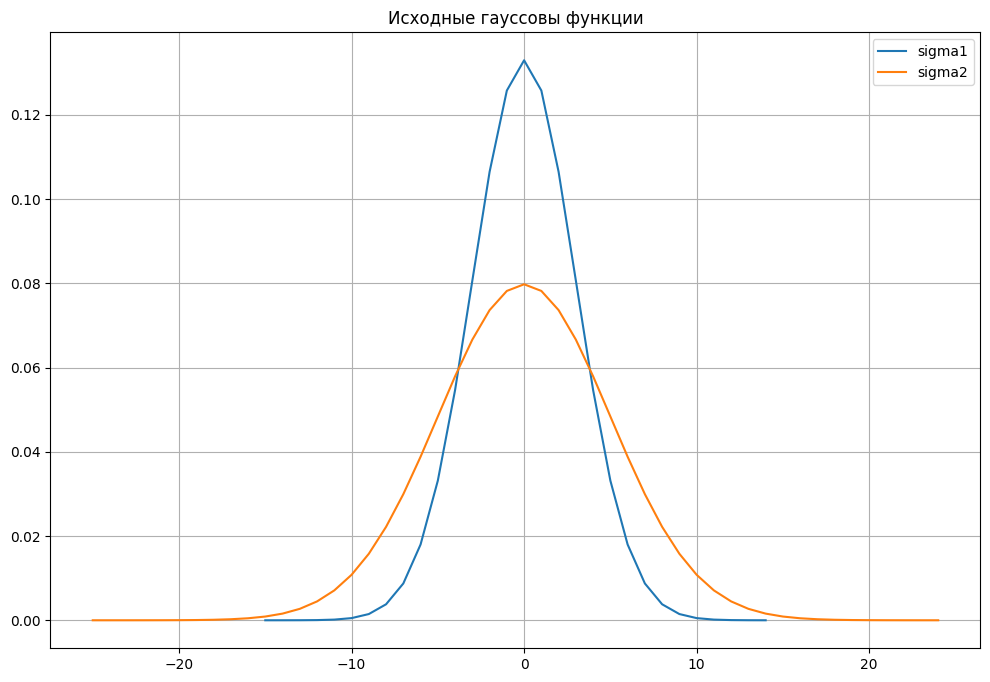

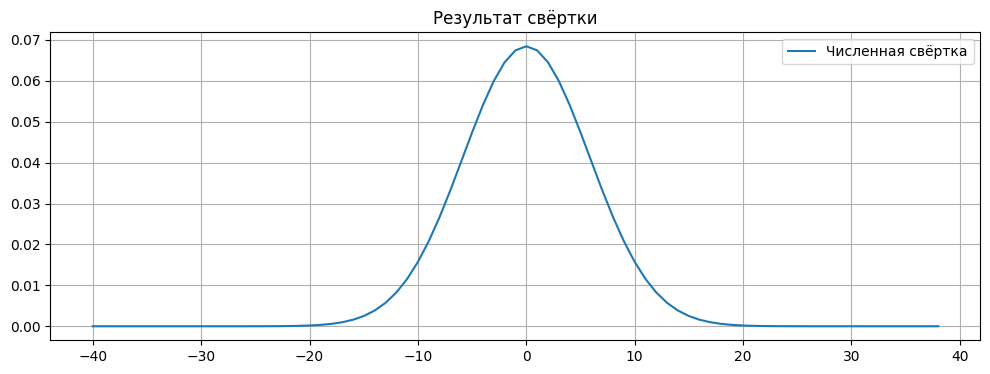

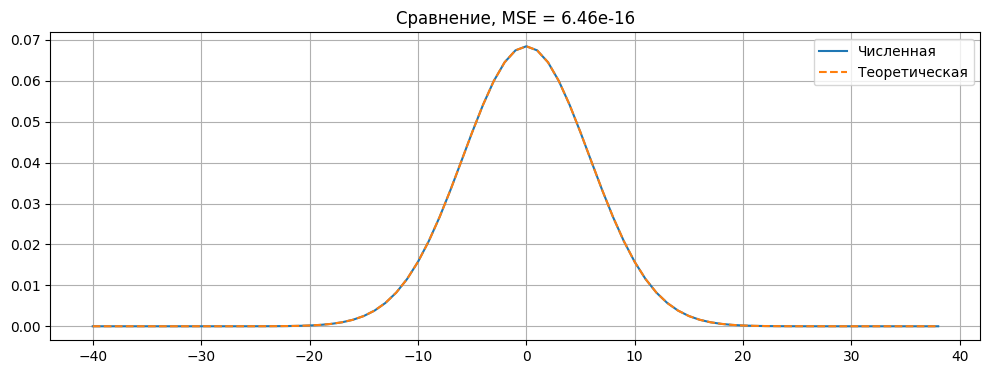

MSE = 6.46e-16


In [27]:
sigma1 = 3
sigma2 = 5

t1 = np.arange(-5 * sigma1, 5 * sigma1)
t2 = np.arange(-5 * sigma2, 5 * sigma2)

f = 1 / (np.sqrt(2 * np.pi) * sigma1) * np.exp(-t1**2 / (2 * sigma1**2))
g = 1 / (np.sqrt(2 * np.pi) * sigma2) * np.exp(-t2**2 / (2 * sigma2**2))

conv_num = np.convolve(f, g, mode='full')

t_conv = np.arange(len(conv_num)) - (5 * (sigma1 + sigma2))

sigma_comb = np.sqrt(sigma1**2 + sigma2**2)
conv_theory = 1 / (np.sqrt(2 * np.pi) * sigma_comb) * np.exp(-t_conv**2 / (2 * sigma_comb**2))

mse = np.mean((conv_num - conv_theory)**2)


plt.figure(figsize=(12, 8))

plt.plot(t1, f, label='sigma1')
plt.plot(t2, g, label='sigma2')
plt.title('Исходные гауссовы функции')
plt.grid(True)
plt.legend()
plt.show()

plt.plot(t_conv, conv_num, label='Численная свёртка')
plt.title('Результат свёртки')
plt.grid(True)
plt.legend()
plt.show()

plt.plot(t_conv, conv_num, label='Численная')
plt.plot(t_conv, conv_theory, '--', label='Теоретическая')
plt.title(f'Сравнение, MSE = {mse:.2e}')
plt.grid(True)
plt.legend()
plt.show()

print(f'MSE = {mse:.2e}')

**Вопросы:**
- Что произойдёт с формой свёртки при увеличении σ?

{При увеличении sigma форма свертки станет более пологой}

## Задание 2. Фильтрация с помощью свёртки: сравнение прямоугольного и гауссовского окон

### Цель
Изучить, как выбор ядра и его длина влияют на подавление высокочастотной составляющей и сохранение низкочастотной.

### Задание
1. Создайте сигнал длительностью 2 секунды, частота дискретизации 1000 Гц, состоящий из суммы двух синусоид:
   - низкая частота \( f_1 = 5 \) Гц, амплитуда 1,
   - высокая частота \( f_2 = 80 \) Гц, амплитуда 0.5.
2. Сгенерируйте прямоугольное окно длины `L` (например, `L = 21`, используйте `scipy.signal.windows.boxcar(L)`), нормализованное так, чтобы сумма коэффициентов была 1.
3. Сгенерируйте гауссовское окно той же длины (используйте `signal.windows.gaussian(L, std=L/5)`), также нормализованное.
4. Примените свёртку с этими окнами (используйте `mode='same'`).
5. Постройте графики:
   - Исходный сигнал (первые 0.5 с).
   - Отфильтрованные сигналы для обоих окон.
6. Вычислите и сравните амплитуды полезной составляющей (5 Гц) и подавленной (80 Гц) после фильтрации. Для этого:
   - Возьмите БПФ сигналов,
   - Измерьте амплитуды на соответствующих частотах.
7. Исследуйте влияние длины окна: повторите для длин `L = 11, 21, 41, 81`.

L=11: rect 5Гц=0.498, 80Гц=0.034 | gauss 5Гц=0.499, 80Гц=0.140
L=21: rect 5Гц=0.491, 80Гц=0.040 | gauss 5Гц=0.496, 80Гц=0.025
L=41: rect 5Гц=0.466, 80Гц=0.018 | gauss 5Гц=0.485, 80Гц=0.000
L=81: rect 5Гц=0.377, 80Гц=0.013 | gauss 5Гц=0.445, 80Гц=0.001
L=21: rect 5Гц=0.491, 80Гц=0.040 | gauss 5Гц=0.496, 80Гц=0.025


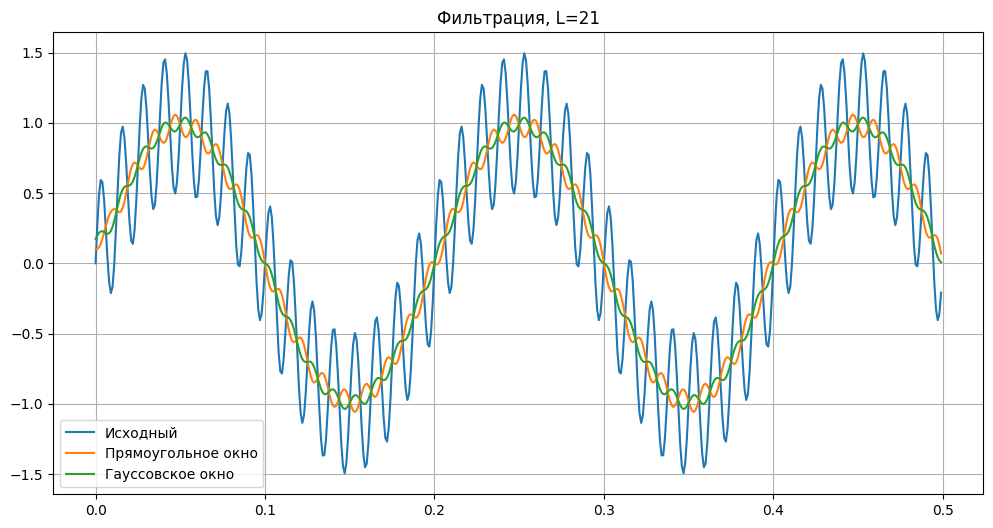

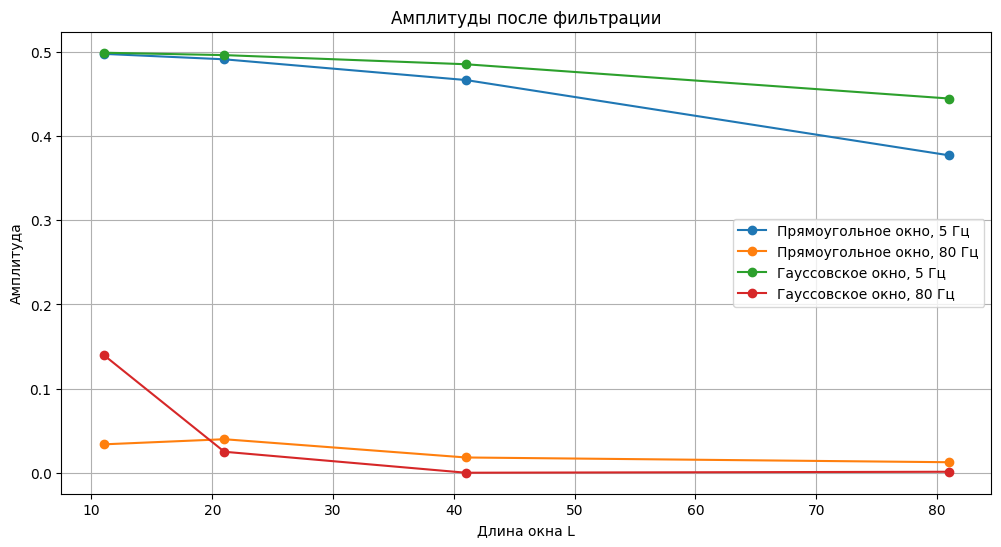

In [28]:
fs = 1000
T = 2
t = np.arange(0, T, 1/fs)

f1 = 5
A1 = 1
f2 = 80
A2 = 0.5
x = A1 * np.sin(2*np.pi*f1*t) + A2 * np.sin(2*np.pi*f2*t)

l = [11, 21, 41, 81, 21]
amp5_rect = []
amp80_rect = []
amp5_gauss = []
amp80_gauss = []

for L in l:
    rect = signal.windows.boxcar(L)
    rect = rect / np.sum(rect)
    y_rect = np.convolve(x, rect, mode='same')

    gauss = signal.windows.gaussian(L, std=L/5)
    gauss = gauss / np.sum(gauss)
    y_gauss = np.convolve(x, gauss, mode='same')

    X = np.fft.fft(x)
    Y_rect = np.fft.fft(y_rect)
    Y_gauss = np.fft.fft(y_gauss)
    freqs = np.fft.fftfreq(len(x), 1/fs)

    amp5_rect.append(np.abs(Y_rect[np.argmin(np.abs(freqs-f1))]) / len(x))
    amp80_rect.append(np.abs(Y_rect[np.argmin(np.abs(freqs-f2))]) / len(x))
    amp5_gauss.append(np.abs(Y_gauss[np.argmin(np.abs(freqs-f1))]) / len(x))
    amp80_gauss.append(np.abs(Y_gauss[np.argmin(np.abs(freqs-f2))]) / len(x))
    print(f"L={L}: rect 5Гц={amp5_rect[-1]:.3f}, 80Гц={amp80_rect[-1]:.3f} | gauss 5Гц={amp5_gauss[-1]:.3f}, 80Гц={amp80_gauss[-1]:.3f}")

plt.figure(figsize=(12, 6))
plt.plot(t[:500], x[:500], label='Исходный')
plt.plot(t[:500], y_rect[:500], label='Прямоугольное окно')
plt.plot(t[:500], y_gauss[:500], label='Гауссовское окно')
plt.title('Фильтрация, L=21')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(l[:-1], amp5_rect[:-1], 'o-', label='Прямоугольное окно, 5 Гц')
plt.plot(l[:-1], amp80_rect[:-1], 'o-', label='Прямоугольное окно, 80 Гц')
plt.plot(l[:-1], amp5_gauss[:-1], 'o-', label='Гауссовское окно, 5 Гц')
plt.plot(l[:-1], amp80_gauss[:-1], 'o-', label='Гауссовское окно, 80 Гц')
plt.title('Амплитуды после фильтрации')
plt.xlabel('Длина окна L')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid()
plt.show()

**Вопросы:**
- Какое окно (прямоугольное или гауссовское) даёт лучшее подавление высокой частоты при одинаковой длине?
- При какой длине прямоугольного и гауссовского окон амплитуда высокочастотного амплитуда падает в 10 раз?
- Как увеличение длины окна влияет на подавление сохранение амплитуды низкой частоты? При какой длине окон она уменьшается более чем на 10%?

{1) гауссовское;
2) 80 Гц амплитуда падает в 10 раз в прямоугольном 41, в гауссовском 21;
3)При росте длины окна усиливается подавление 80 Гц,5 Гц остлабляется. При 81 уменьшение более 10%}

## Задание 3. Поиск временной задержки с помощью кросс-корреляции

### Цель
Определить временной сдвиг между двумя сигналами в присутствии шума и оценить влияние уровня шума на точность.

### Задание
1. Сгенерируйте сигнал длительностью 1 секунду (fs=1000 Гц), представляющий собой сумму 100 синусоид со случайными частотами (в диапазоне 10–100 Гц), амплитудами (в диапазоне 0.5–1.5 Гц) и фазами (в диапазоне 0–2$\pi$). Воспользуйтесь функцией `numpy.random.uniform`. Нормализуйте полученный сигнал в интервале $[-1;1]$. Назовём его `x`.
2. Создайте второй сигнал `y`, который является сдвинутой во времени копией `x` на `delay` отсчётов (выберите задержку, например, 100 отсчётов) и добавьте к нему случайный сигнал (шум) с уровнем `noise_level` (например, 0.1) с помощью функции `numpy.random.randn`.
3. Вычислите кросс-корреляцию `corr = np.correlate(x, y, mode='full')` и найдите индекс максимума. Оцените задержку как `delay_est = argmax(corr) - (len(x)-1)` (поскольку `mode='full'` даёт диапазон от -N+1 до N-1).
4. Повторите эксперимент для различных уровней шума в диапазоне от `0` до `2`.
5. Для двух уровней шума (0.3 и 2) постройте график кросс-корреляции и отметьте положение истинной и найденной задержки.

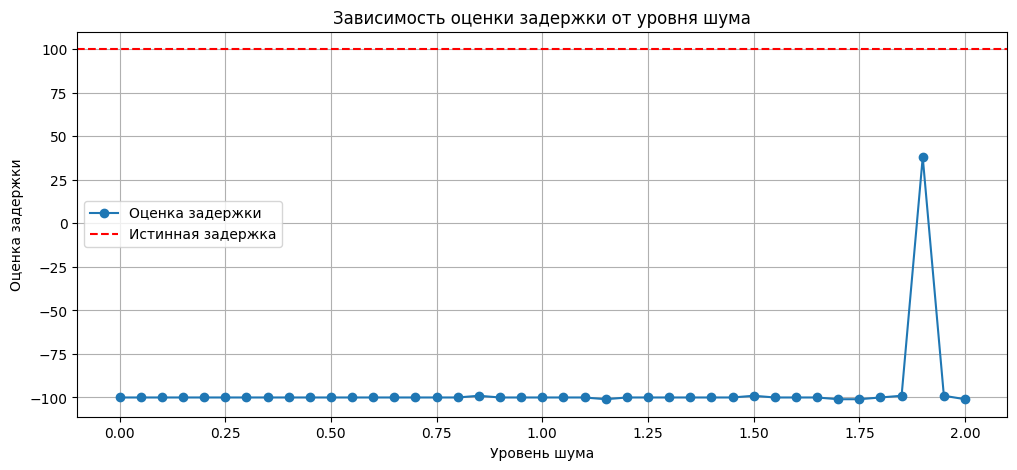

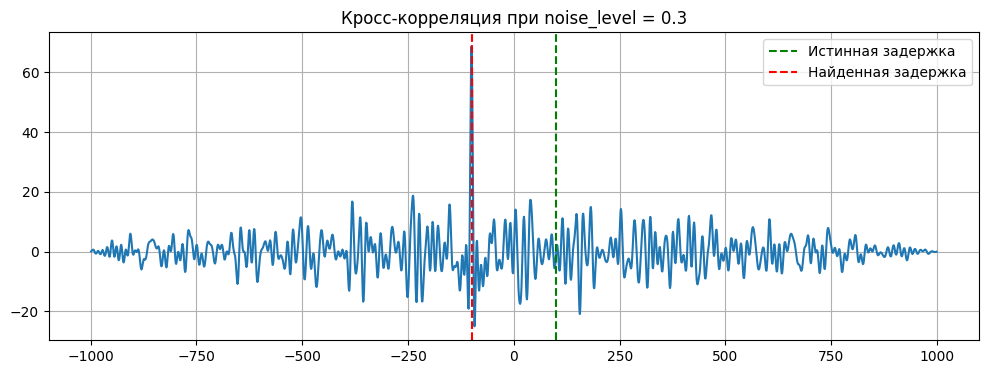

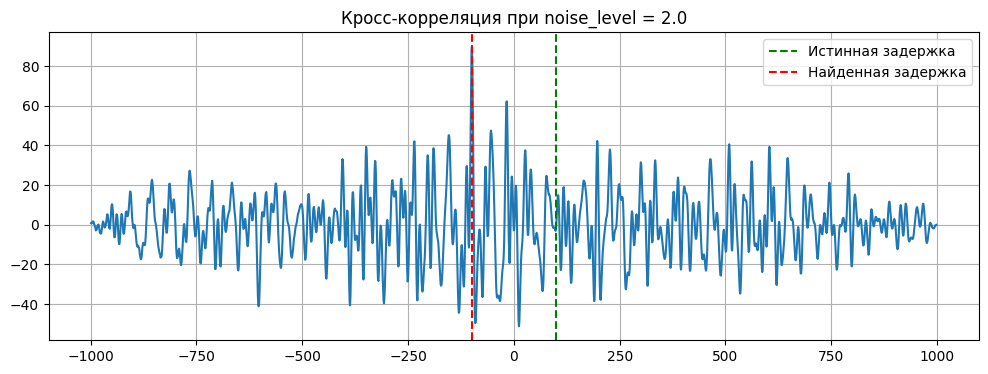

In [29]:
np.random.seed(42)
fs = 1000
t = np.arange(0, 1, 1 / fs)

freqs = np.random.uniform(10, 100, 100)
amps = np.random.uniform(0.5, 1.5, 100)
phases = np.random.uniform(0, 2 * np.pi, 100)

x = np.zeros_like(t)
for f, a, p in zip(freqs, amps, phases):
    x += a * np.sin(2 * np.pi * f * t + p)
x = x / np.max(np.abs(x))

delay_true = 100
noise_levels = np.linspace(0, 2, 41)
delays_est = []

for nl in noise_levels:
    y = np.concatenate([np.zeros(delay_true), x[:-delay_true]])
    y = y + nl * np.random.randn(len(x))

    corr = np.correlate(x, y, mode='full')
    idx_max = np.argmax(corr)
    delay_est = idx_max - (len(x)-1)
    delays_est.append(delay_est)


plt.figure(figsize=(12, 5))
plt.plot(noise_levels, delays_est, 'o-', label='Оценка задержки')
plt.axhline(delay_true, color='r', linestyle='--', label='Истинная задержка')
plt.xlabel('Уровень шума')
plt.ylabel('Оценка задержки')
plt.title('Зависимость оценки задержки от уровня шума')
plt.grid(True)
plt.legend()
plt.show()

nl = 0.3
y = np.roll(x, delay_true)
y[:delay_true] = 0
y += nl * np.random.randn(len(y))
corr = np.correlate(x, y, mode='full')
lags = np.arange(-len(x)+1, len(x))
idx_max = np.argmax(corr)
delay_est = lags[idx_max]

plt.figure(figsize=(12, 4))
plt.plot(lags, corr)
plt.axvline(delay_true, color='g', linestyle='--', label='Истинная задержка')
plt.axvline(delay_est, color='r', linestyle='--', label='Найденная задержка')
plt.title('Кросс-корреляция при noise_level = 0.3')
plt.grid(True)
plt.legend()
plt.show()

nl = 2.0
y = np.roll(x, delay_true)
y[:delay_true] = 0
y += nl * np.random.randn(len(y))
corr = np.correlate(x, y, mode='full')
lags = np.arange(-len(x)+1, len(x))
idx_max = np.argmax(corr)
delay_est = lags[idx_max]

plt.figure(figsize=(12, 4))
plt.plot(lags, corr)
plt.axvline(delay_true, color='g', linestyle='--', label='Истинная задержка')
plt.axvline(delay_est, color='r', linestyle='--', label='Найденная задержка')
plt.title('Кросс-корреляция при noise_level = 2.0')
plt.grid(True)
plt.legend()
plt.show()

**Вопросы:**
- Как зависит точность оценки задержки от уровня шума? При каком уровне шума вычисленная задержка отличается от истинной более чем на 10%? При каком уровне шума вычисленная задержка становится практически неотличима от `0`?
- Почему при высоком уровне шума могут появляться ложные пики?

{Точность оценки задержки убывает с ростом уровня шума. До уровня 1.8 оценка близка к истинной. В зоне от 0 до 2 неотличима от 0.
Шум создает совпадения и максимум корреляции смещается.}

## Задание 4. Обнаружение шаблона в зашумлённом сигнале

### Цель
Найти местоположение сигнала, имеющего форму гауссова импульса, модулированного синусоидой, в смеси с шумом. Исследовать влияние отношения сигнал/шум на точность обнаружения.

### Задание
1. Создайте шаблон `template` – произведение гауссовой огибающей (σ=100 отсчётов) на синусоиду частотой 20 Гц (при fs=1000 Гц). Длина шаблона примерно 6σ.
2. Создайте длинный сигнал `long_signal` длиной 2000 отсчётов, состоящий из:
   - случайного сигнала (шума), созданного с помощью `numpy.random.randn()` с единичной амплитудой,
   - вставленного в случайную позицию шаблона, умноженного на амплитуду `A` (например, 2).
3. Используйте кросс-корреляцию `np.correlate(long_signal, template, mode='valid')` для поиска позиции шаблона. Найдите индекс максимума корреляции.
4. Повторите эксперимент для разных отношений сигнал/шум (SNR), варьируя амплитуду шаблона от 0.2 до 5.
5. Для одного значения SNR (например, 1) визуализируйте: исходный длинный сигнал, шаблон, результат кросс-корреляции с отмеченным пиком.

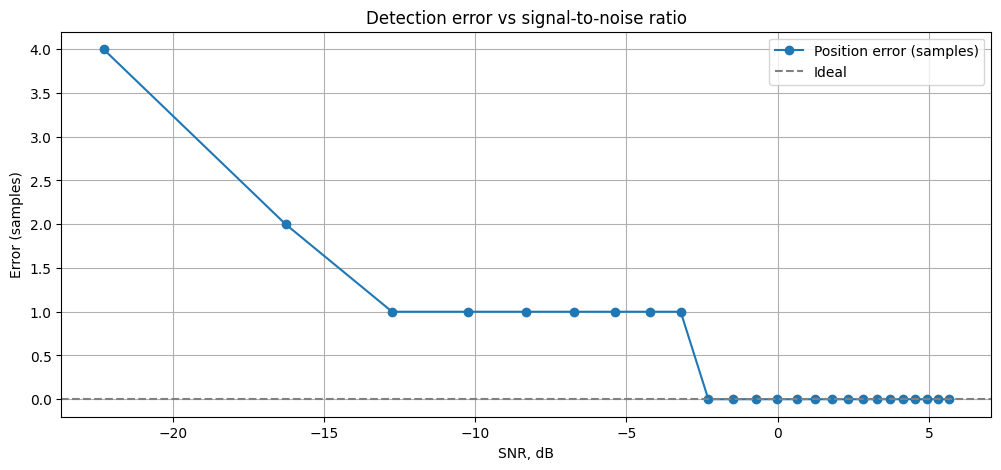

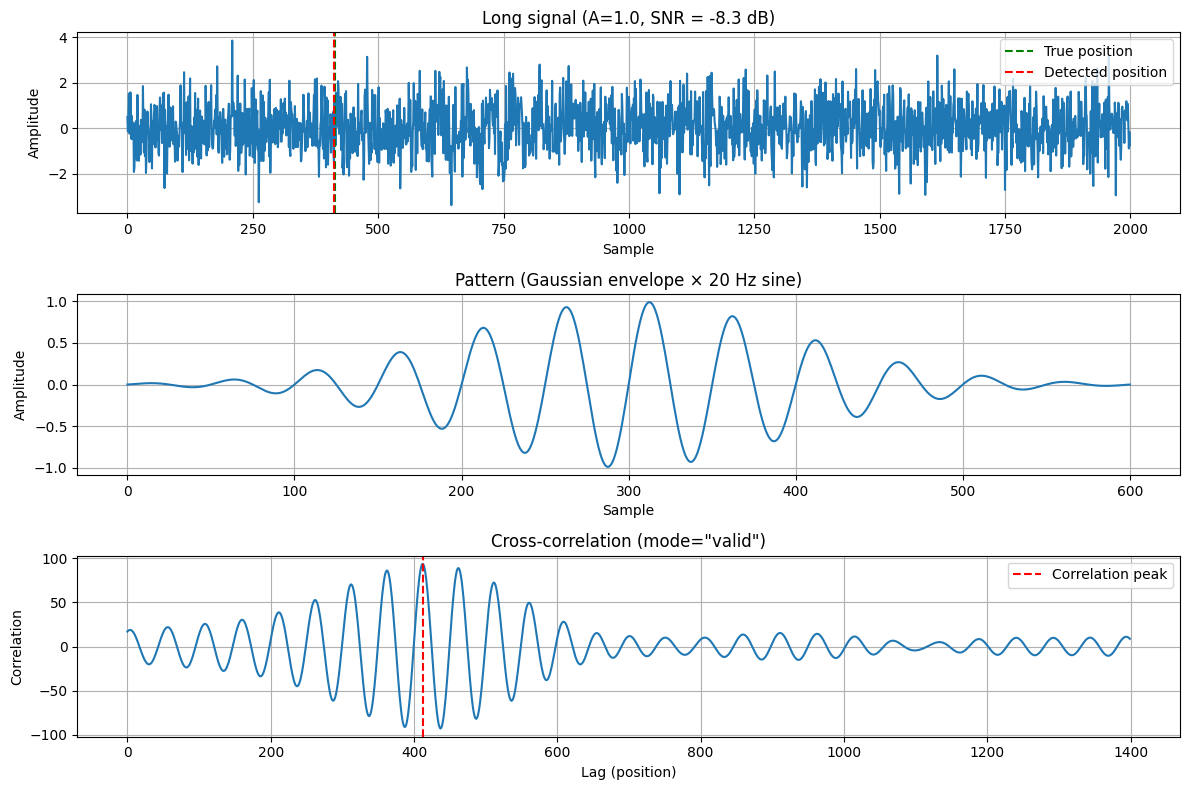

In [30]:
np.random.seed(42)
Fs = 1000
width = 100

M = 6 * width + 1
time_vec = np.arange(M) - M // 2
gaussian_env = np.exp(-time_vec**2 / (2 * width**2))
pattern = gaussian_env * np.sin(2 * np.pi * 20 * time_vec / Fs)

long_signal = 2000
amplitudes = np.linspace(0.2, 5.0, 25)
position_errors = []
snr_list = []

background = np.random.randn(long_signal)
true_location = np.random.randint(0, long_signal - len(pattern) + 1)

for coeff in amplitudes:
    mixed = background.copy()
    mixed[true_location:true_location + len(pattern)] += coeff * pattern

    xcorr = np.correlate(mixed, pattern, mode='valid')
    estimated_loc = np.argmax(xcorr)

    position_errors.append(abs(estimated_loc - true_location))
    pattern_rms = np.sqrt(np.mean(pattern**2))
    linear_snr = coeff * pattern_rms
    snr_list.append(20 * np.log10(linear_snr))

plt.figure(figsize=(12, 5))
plt.plot(snr_list, position_errors, 'o-', label='Position error (samples)')
plt.axhline(0, color='gray', linestyle='--', label='Ideal')
plt.xlabel('SNR, dB')
plt.ylabel('Error (samples)')
plt.title('Detection error vs signal-to-noise ratio')
plt.grid(True)
plt.legend()
plt.show()

demo_amp = 1.0
demo_signal = background.copy()
demo_signal[true_location:true_location + len(pattern)] += demo_amp * pattern
demo_xcorr = np.correlate(demo_signal, pattern, mode='valid')
demo_peak = np.argmax(demo_xcorr)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(demo_signal)
plt.axvline(true_location, color='green', linestyle='--', label='True position')
plt.axvline(demo_peak, color='red', linestyle='--', label='Detected position')
plt.title(f'Long signal (A={demo_amp}, SNR = {20*np.log10(demo_amp*np.sqrt(np.mean(pattern**2))):.1f} dB)')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(pattern)
plt.title('Pattern (Gaussian envelope × 20 Hz sine)')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(demo_xcorr)
plt.axvline(demo_peak, color='red', linestyle='--', label='Correlation peak')
plt.title('Cross-correlation (mode="valid")')
plt.xlabel('Lag (position)')
plt.ylabel('Correlation')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**Вопросы:**
- При каком SNR результаты измерения резко ухудшаются?

{Резальтаты измерения ухудшаются при SNR 3, при SNR 13 ухудшения ещё сильнее}

## Задание 5. Поиск фрагмента в реальном аудиосигнале

### Цель
Применить кросс-корреляцию для нахождения заданного фрагмента в аудиофайле. Фрагмент и основной файл предоставлены (студентам нужно будет загрузить их).

### Задание
1. Загрузите аудиофайл `full_audio.wav` и фрагмент `fragment.wav`. Используйте `scipy.io.wavfile.read`.
2. Вычислите кросс-корреляцию между полным сигналом и фрагментом.
3. Найдите позицию максимального значения корреляции и определите временное смещение (в отсчётах и в секундах).
4. Постройте график кросс-корреляции и отметьте найденный пик.
5. Вырежьте из полного сигнала участок, соответствующий найденной позиции, и прослушайте его (используйте `Audio`). Убедитесь, что он совпадает с фрагментом.

In [31]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O full_audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav"
!wget -O fragment.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/fragment.wav"

--2026-05-30 08:50:06--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav [following]
--2026-05-30 08:50:06--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6990446 (6.7M) [audio/wav]
Saving to: ‘full_audio.wav’

full_audio.wav      100%[===================>]   6.67M  --.-KB/s    in 0.08s   

2026-05-30 08:50:07 (81.3 MB/s) - ‘full_audio.wav’ saved [6990446/6

/tmp/ipykernel_10607/1142464737.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_full, full = wavfile.read('full_audio.wav')
/tmp/ipykernel_10607/1142464737.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_frag, frag = wavfile.read('fragment.wav')


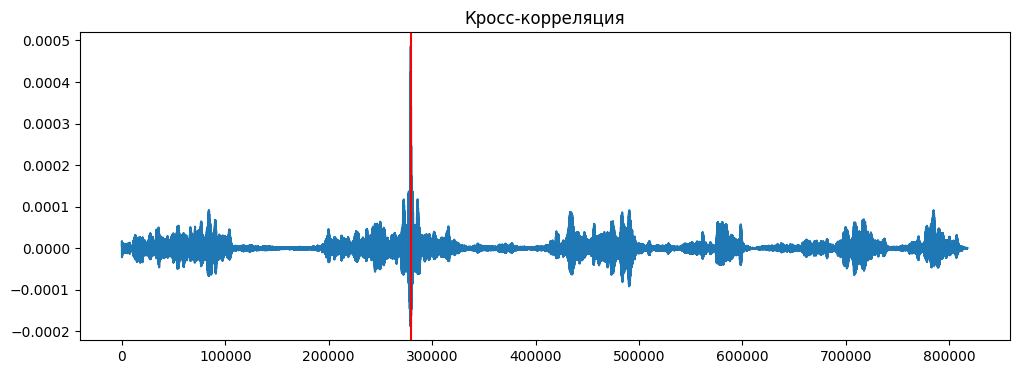

Фрагмент найден на отсчёте 279235 (секунд: 6.332)


In [32]:
fs_full, full = wavfile.read('full_audio.wav')
fs_frag, frag = wavfile.read('fragment.wav')

if full.ndim > 1:
    full = full[:, 0]
if frag.ndim > 1:
    frag = frag[:, 0]

full = full / 32767.0
frag = frag / 32767.0

corr = np.correlate(full, frag, mode='valid')
peak_idx = np.argmax(corr)

extracted = full[peak_idx:peak_idx+len(frag)]

plt.figure()
plt.plot(corr)
plt.axvline(peak_idx, color='r')
plt.title('Кросс-корреляция')
plt.show()
print(f'Фрагмент найден на отсчёте {peak_idx} (секунд: {peak_idx/fs_full:.3f})')
display(Audio(extracted, rate=fs_full))
display(Audio(frag, rate=fs_frag))

**Вопросы:**
- Почему перед вычислением корреляции сигналы следует нормализовать?
- Сколько раз в сигнале встречается вырезанное во фрагменте слово? Удаётся ли с помощью корреляционного анализа определить его во всех случаях? Возникают ли ложные максимумы?
- Что будет, если фрагмент не содержится в полном сигнале? Как это отразится на корреляции?

{Корелляция позволяет сделать сравнение корректным по амплитуде в диапазоне от -1 до 1. Встречается 1 раз. Удается. Не возникают. Если фрагмента не будет, то не будет ярко выраженного пика}